<a href="https://colab.research.google.com/github/ArpitaRPatki/NLP-LAB/blob/main/NLP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate 150 synthetic samples
positive_phrases = ["great quality", "love this", "amazing product", "best purchase", "highly recommended", "works perfectly", "so happy", "excellent service"]
negative_phrases = ["bad quality", "hate this", "useless product", "worst purchase", "not recommended", "broken item", "not happy", "terrible service"]

texts = []
labels = []
for i in range(75):
    texts.append(f"This is {np.random.choice(positive_phrases)}")
    labels.append("positive")
    texts.append(f"This is {np.random.choice(negative_phrases)}")
    labels.append("negative")

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [15]:
# Create the pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', MultinomialNB()),
])

# Train
model.fit(X_train, y_train)
print("Training complete on 150 samples.")

Training complete on 150 samples.


In [16]:
# 10 specific sentences for prediction
new_sentences = [
    "I absolutely love this amazing product",
    "This is the worst purchase ever",
    "Great quality and excellent service",
    "The item is broken and useless",
    "I am very happy with this",
    "Terrible service, not recommended",
    "It works perfectly",
    "Bad quality, hate this",
    "Highly recommended purchase",
    "Not happy at all"
]

predictions = model.predict(new_sentences)

print(f"{'Sentence':<40} | {'Prediction'}")
print("-" * 55)
for text, pred in zip(new_sentences, predictions):
    print(f"{text:<40} | {pred}")

Sentence                                 | Prediction
-------------------------------------------------------
I absolutely love this amazing product   | positive
This is the worst purchase ever          | negative
Great quality and excellent service      | positive
The item is broken and useless           | negative
I am very happy with this                | negative
Terrible service, not recommended        | negative
It works perfectly                       | positive
Bad quality, hate this                   | negative
Highly recommended purchase              | positive
Not happy at all                         | negative



Model Accuracy: 90.00%


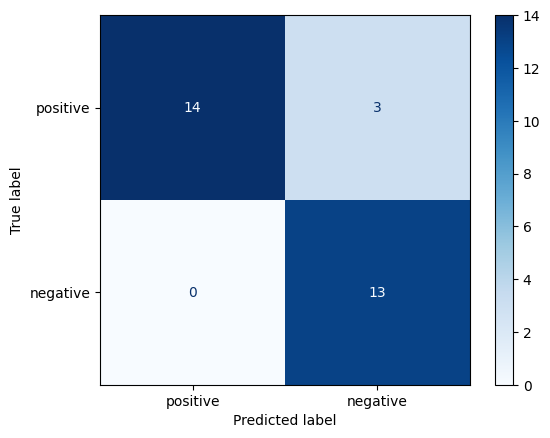

In [17]:
# Evaluate performance
y_pred = model.predict(X_test)
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["positive", "negative"])
ConfusionMatrixDisplay(cm, display_labels=["positive", "negative"]).plot(cmap=plt.cm.Blues)
plt.show()